# Notebook 1 — Poverty & Cancer SDOH Analysis

**TruBridge Externship | Iowa Colorectal Cancer (2016–2020)**

Analyzes poverty rates (ACS Table S1701) vs late-stage colorectal cancer across Iowa counties.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd                          # choropleth maps
from scipy.stats import pearsonr, ttest_ind, f_oneway, probplot, shapiro


## 1. Load cancer registry data

> **Colab:** Upload all CSV files via the folder icon before running.

In [2]:
# ── Upload: county_colorectal_latestage_2016-2020.csv ────────────────────────
cancer_df = pd.read_csv('county_colorectal_latestage_2016-2020.csv')
cancer_df.rename(columns={'identifier':'County','AAR':'Number of New Cases per 100K',
                           'AARprob':'Cancer Risk Probability'}, inplace=True)
cancer_df.drop(columns='AARsd', inplace=True)
cancer_df.sort_values('County', inplace=True)
cancer_df.reset_index(drop=True, inplace=True)
cancer_df.columns = cancer_df.columns.str.strip()
assert len(cancer_df) == 99, f"Expected 99 counties, got {len(cancer_df)}"
print(f"Cancer data: {len(cancer_df)} counties | "
      f"Cancer Risk Probability range: {cancer_df['Cancer Risk Probability'].min():.4f}–{cancer_df['Cancer Risk Probability'].max():.4f}")
cancer_df.head()


Cancer data: 99 counties | Cancer Risk Probability range: 0.0100–0.5700


,County,Number of New Cases per 100K,Cancer Risk Probability,mapPop
0,Adair,18.99,0.25,5.2005
1,Adams,18.90,0.23,3.6579
2,Allamakee,18.15,0.11,8.3985
3,Appanoose,19.28,0.33,9.6327
4,Audubon,19.13,0.29,5.3292


## 2. Extract and prepare poverty SDOH data

In [3]:
# ── Upload: ACS - S1701 - Poverty Status in IA - 2020 5 Yr Estimates (2016-20).csv
poverty_raw = pd.read_csv('ACS - S1701 - Poverty Status in IA - 2020 5 Yr Estimates (2016-20).csv')

sdoh_categories = {
    'Overall_Poverty':       'Population for whom poverty status is determined',
    'Child_Poverty':         'Under 18 years',
    'Senior_Poverty':        '65 years and over',
    'Male_Poverty':          'Male',
    'Female_Poverty':        'Female',
    'White_Poverty':         'White alone',
    'Black_Poverty':         'Black or African American alone',
    'Hispanic_Poverty':      'Hispanic or Latino origin (of any race)',
    'Low_Education_Poverty': 'Less than high school graduate',
    'High_Education_Poverty':"Bachelor\'s degree or higher",
    'Unemployment_Poverty':  'Unemployed',
    'No_Work_Poverty':       'Did not work',
}

def extract_poverty_category(label):
    row = poverty_raw[poverty_raw['Label (Grouping)'].str.strip() == label.strip()]
    if row.empty: print(f"Warning: '{label}' not found"); return None
    cols = [c for c in poverty_raw.columns
            if 'Percent below poverty level!!Estimate' in c and 'County, Iowa' in c]
    return pd.DataFrame([{'County': c.split('!!')[0].replace(' County, Iowa',''), label: row.iloc[0][c]}
                         for c in cols])

def clean_pct(v):
    if pd.isna(v): return np.nan
    s = str(v).strip()
    if s.startswith('('): return np.nan   # ACS suppressed estimate
    if s in ('-','','N','X'): return np.nan
    try: return float(s.replace('%','').replace(',','').strip())
    except: return np.nan

frames = []
for name, label in sdoh_categories.items():
    tmp = extract_poverty_category(label)
    if tmp is not None:
        tmp.columns = ['County', name]
        frames.append(tmp.set_index('County'))

sdoh_df = pd.concat(frames, axis=1).reset_index()
for col in sdoh_categories:
    sdoh_df[col] = sdoh_df[col].apply(clean_pct)

poverty_df = cancer_df.merge(sdoh_df, on='County', how='inner')
poverty_df.to_csv('iowa_colorectal_cancer_poverty_sdoh_2016-2020.csv', index=False)

# FIX: define median_pov once here so all downstream cells share it
median_pov = poverty_df['Overall_Poverty'].median()

print(f"Merged: {len(poverty_df)} counties (expected 99) | median poverty: {median_pov:.1f}%")
print("Missing values per SDOH column:")
print(poverty_df[list(sdoh_categories.keys())].isnull().sum().to_string())
poverty_df.head()


Merged: 99 counties (expected 99) | median poverty: 10.9%
Missing values per SDOH column:
Overall_Poverty           0
Child_Poverty             0
Senior_Poverty            0
Male_Poverty              0
Female_Poverty            0
White_Poverty             0
Black_Poverty             5
Hispanic_Poverty          0
Low_Education_Poverty     0
High_Education_Poverty    0
Unemployment_Poverty      0
No_Work_Poverty           0


,County,Number of New Cases per 100K,Cancer Risk Probability,mapPop,Overall_Poverty,Child_Poverty,Senior_Poverty,Male_Poverty,Female_Poverty,White_Poverty,Black_Poverty,Hispanic_Poverty,Low_Education_Poverty,High_Education_Poverty,Unemployment_Poverty,No_Work_Poverty
0,Adair,18.99,0.25,5.2005,11.1,14.1,10.0,8.4,13.8,10.8,15.2,11.2,15.8,1.6,26.0,21.2
1,Adams,18.90,0.23,3.6579,13.4,14.7,12.0,10.4,16.3,12.9,25.0,55.3,42.9,4.5,63.5,27.1
2,Allamakee,18.15,0.11,8.3985,11.4,15.2,6.9,9.5,13.4,11.7,0.0,44.4,22.6,3.7,32.5,18.2
3,Appanoose,19.28,0.33,9.6327,19.7,30.2,6.0,21.2,18.2,19.7,8.2,24.0,29.3,2.4,42.5,26.2
4,Audubon,19.13,0.29,5.3292,11.3,23.9,6.8,9.3,13.3,10.2,NaN,47.7,22.0,3.3,52.6,16.0


## 3. Geographic overview

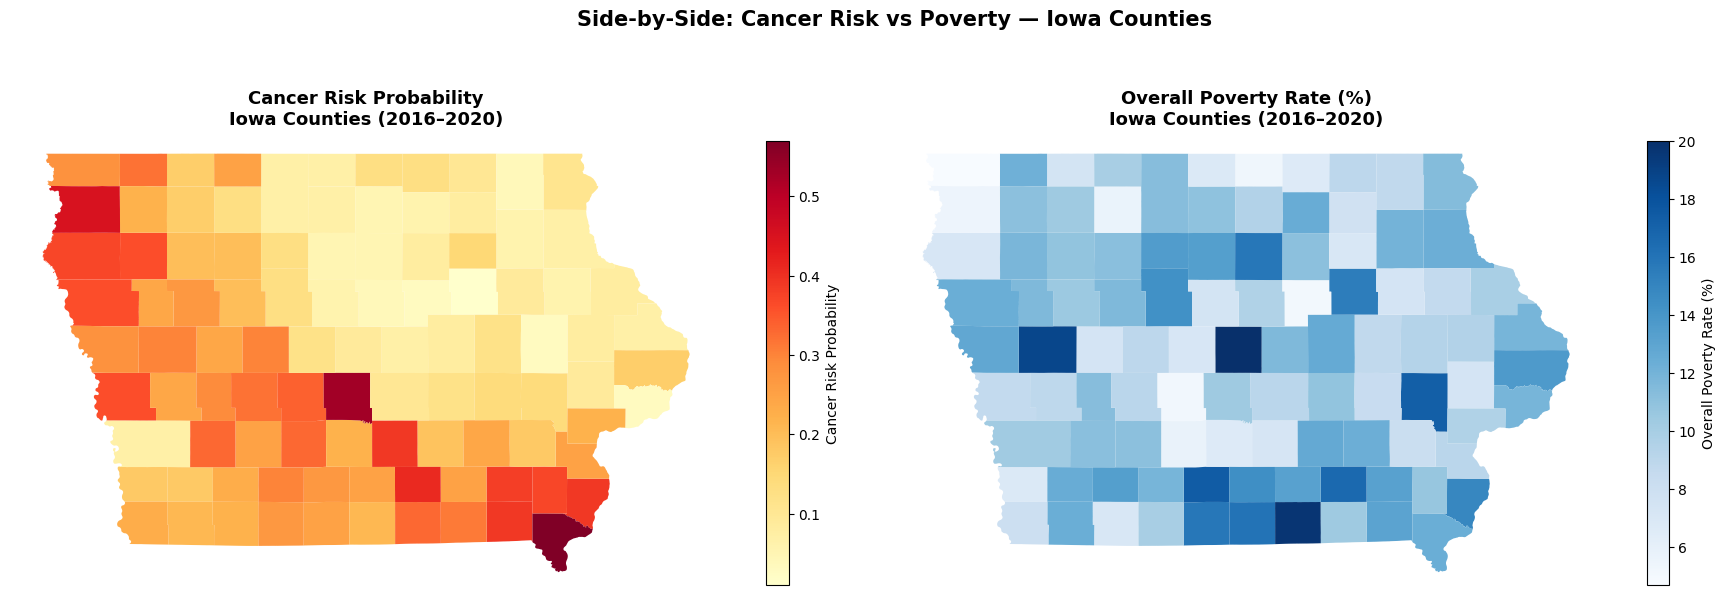

In [4]:
# ── Choropleth: Cancer Risk Probability vs Overall Poverty ───────────────────
# Downloads Iowa county boundaries from US Census TIGER (requires internet)
gdf      = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip")
iowa_gdf = gdf[gdf['STATEFP'] == '19'].copy()
iowa_gdf['NAME'] = iowa_gdf['NAME'].str.strip()
map_df   = iowa_gdf.merge(poverty_df, left_on='NAME', right_on='County', how='left')

unmatched = map_df[map_df['Cancer Risk Probability'].isna()]['NAME'].tolist()
if unmatched: print(f"Warning: {len(unmatched)} unmatched counties: {unmatched}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
map_df.plot(column='Cancer Risk Probability', ax=axes[0], legend=True, cmap='YlOrRd',
            missing_kwds={'color':'lightgrey'}, legend_kwds={'label':'Cancer Risk Probability','shrink':0.7})
axes[0].set_title('Cancer Risk Probability\nIowa Counties (2016–2020)', fontsize=13, fontweight='bold')
axes[0].axis('off')
map_df.plot(column='Overall_Poverty', ax=axes[1], legend=True, cmap='Blues',
            missing_kwds={'color':'lightgrey'}, legend_kwds={'label':'Overall Poverty Rate (%)','shrink':0.7})
axes[1].set_title('Overall Poverty Rate (%)\nIowa Counties (2016–2020)', fontsize=13, fontweight='bold')
axes[1].axis('off')
plt.suptitle('Side-by-Side: Cancer Risk vs Poverty — Iowa Counties', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## 4. Distributions and relationships

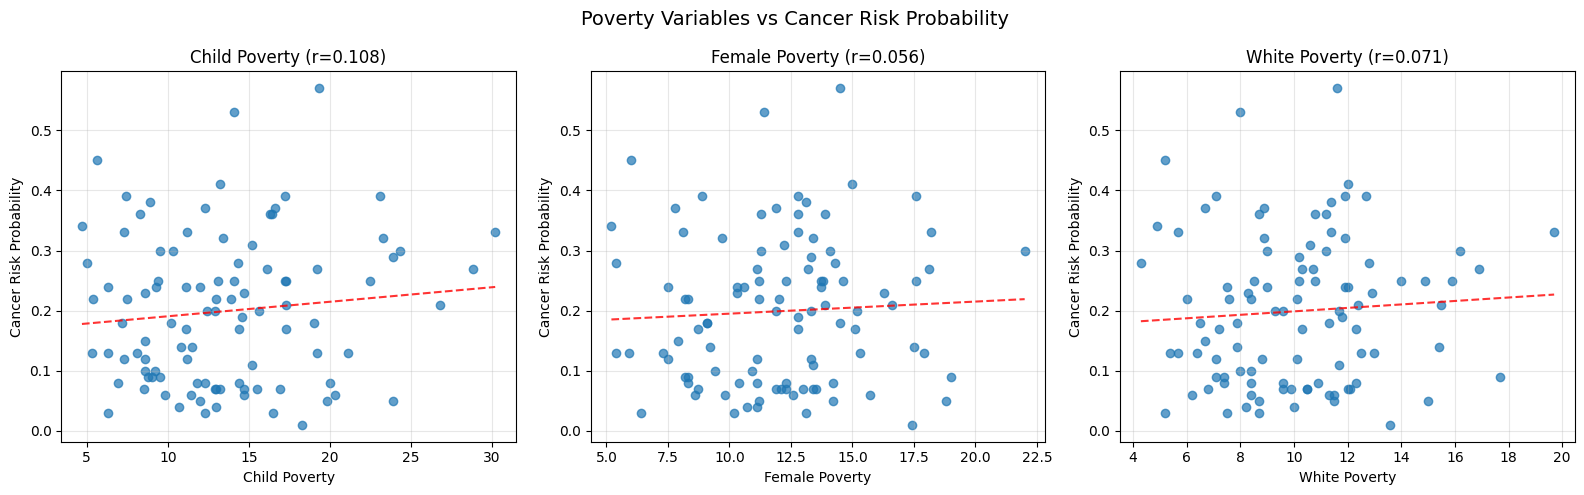

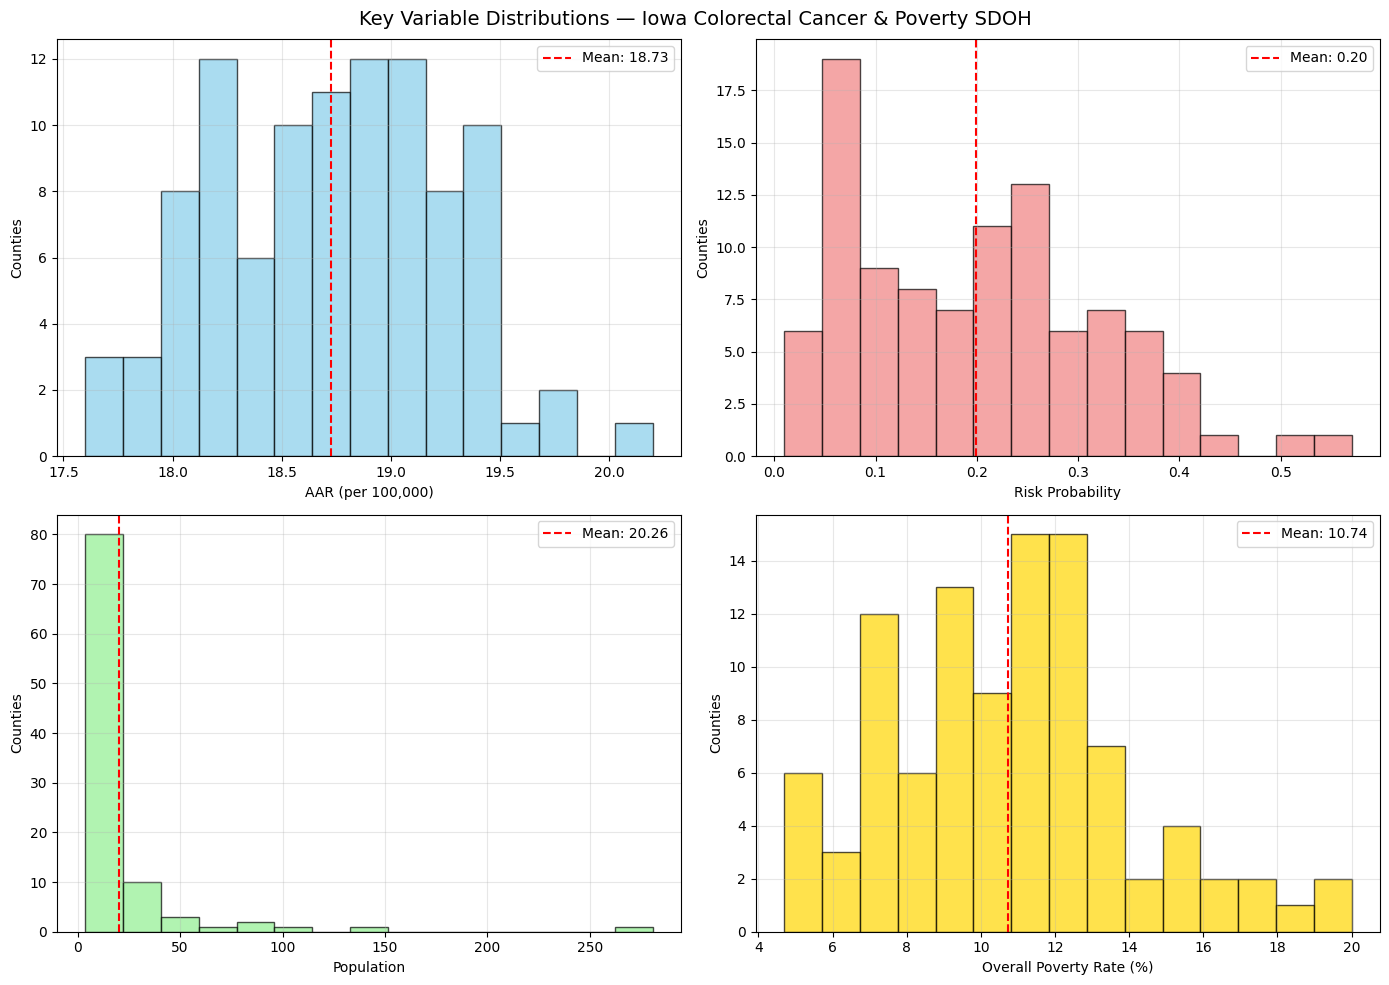

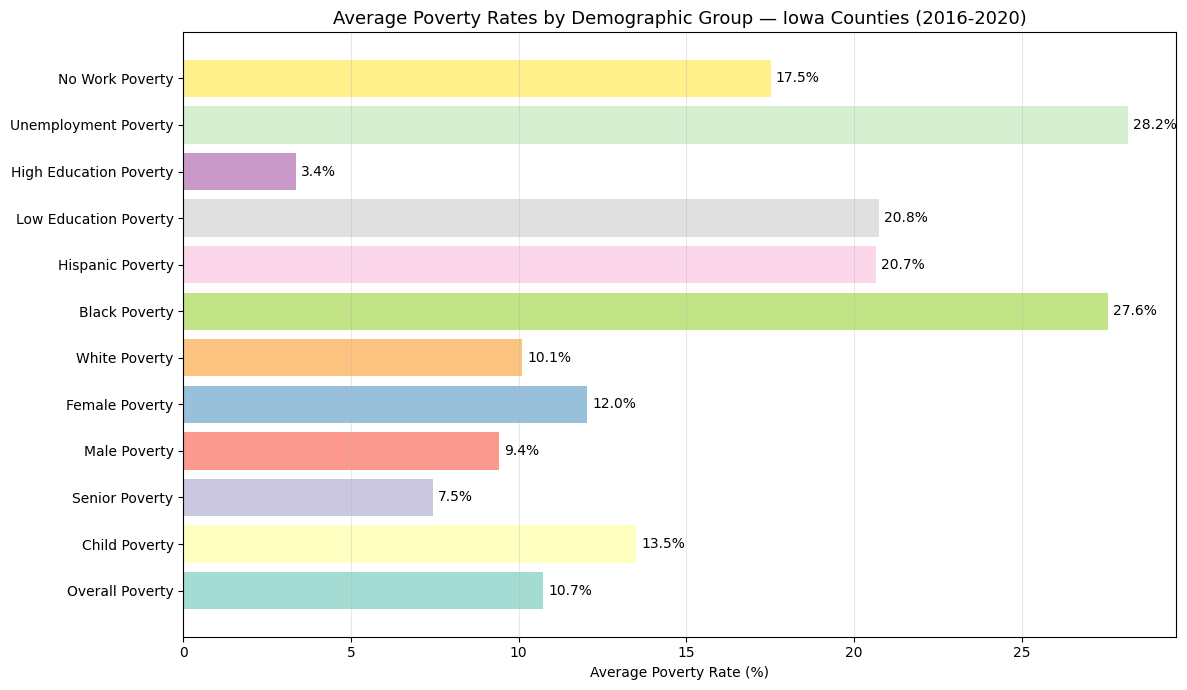

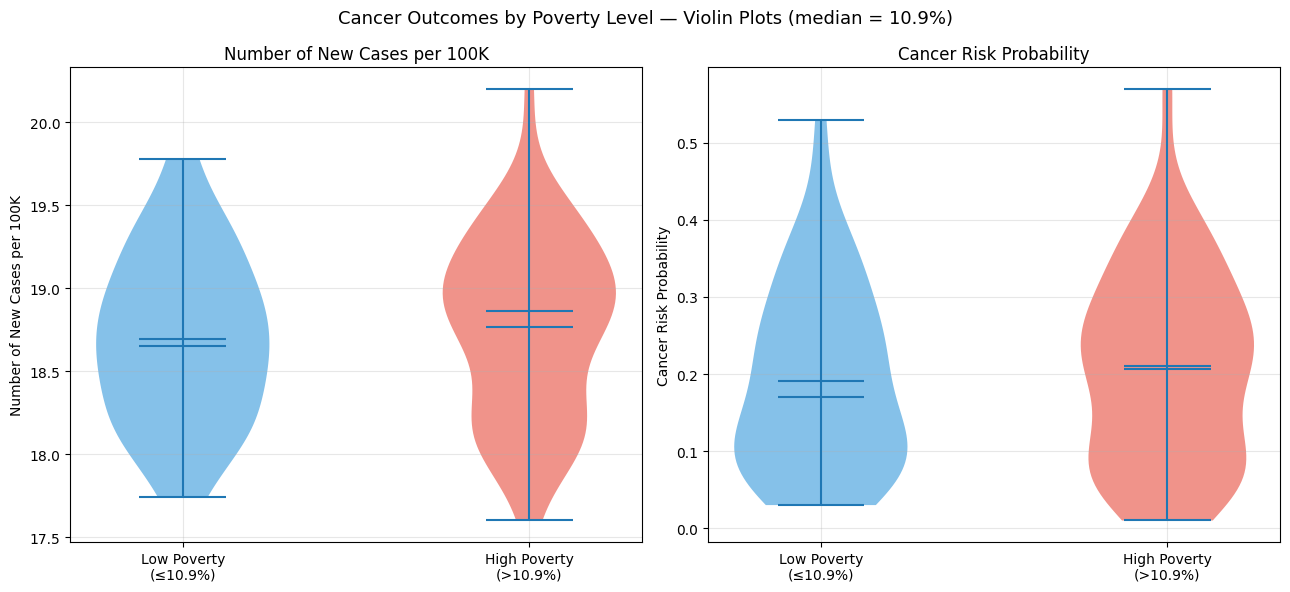

In [5]:
# ── Scatter plots: selected poverty variables vs Cancer Risk Probability ──────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, var in zip(axes, ['Child_Poverty','Female_Poverty','White_Poverty']):
    clean = poverty_df[[var,'Cancer Risk Probability']].dropna()
    x, y  = clean[var].values, clean['Cancer Risk Probability'].values
    ax.scatter(x, y, alpha=0.7)
    x_s = np.sort(x)
    ax.plot(x_s, np.poly1d(np.polyfit(x,y,1))(x_s), 'r--', alpha=0.8)
    ax.set_xlabel(var.replace('_',' ')); ax.set_ylabel('Cancer Risk Probability')
    ax.set_title(f'{var.replace("_"," ")} (r={np.corrcoef(x,y)[0,1]:.3f})'); ax.grid(True, alpha=0.3)
plt.suptitle('Poverty Variables vs Cancer Risk Probability', fontsize=14)
plt.tight_layout(); plt.show()

# ── Key variable distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax,(col,color,xlabel) in zip(axes.flat,[
    ('Number of New Cases per 100K','skyblue',   'AAR (per 100,000)'),
    ('Cancer Risk Probability',     'lightcoral','Risk Probability'),
    ('mapPop',                      'lightgreen','Population'),
    ('Overall_Poverty',             'gold',      'Overall Poverty Rate (%)')]):
    ax.hist(poverty_df[col].dropna(), bins=15, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(poverty_df[col].mean(), color='red', linestyle='--', label=f'Mean: {poverty_df[col].mean():.2f}')
    ax.set_xlabel(xlabel); ax.set_ylabel('Counties'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Key Variable Distributions — Iowa Colorectal Cancer & Poverty SDOH', fontsize=14)
plt.tight_layout(); plt.show()

# ── Average poverty rates by demographic group ───────────────────────────────
means  = [poverty_df[v].mean() for v in sdoh_categories]
labels = [v.replace('_',' ') for v in sdoh_categories]
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(labels, means, color=plt.cm.Set3(np.linspace(0,1,len(labels))), alpha=0.8)
for bar, val in zip(bars, means):
    ax.text(val+0.15, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center')
ax.set_xlabel('Average Poverty Rate (%)'); ax.grid(axis='x', alpha=0.3)
ax.set_title('Average Poverty Rates by Demographic Group — Iowa Counties (2016-2020)', fontsize=13)
plt.tight_layout(); plt.show()

# ── Violin plots: high vs low poverty (uses median_pov from prep cell) ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, col in zip(axes, ['Number of New Cases per 100K','Cancer Risk Probability']):
    groups = [poverty_df[poverty_df['Overall_Poverty'] <= median_pov][col].dropna(),
              poverty_df[poverty_df['Overall_Poverty'] >  median_pov][col].dropna()]
    parts  = ax.violinplot(groups, positions=[1,2], showmedians=True, showmeans=True)
    parts['bodies'][0].set_facecolor('#3498db'); parts['bodies'][0].set_alpha(0.6)
    parts['bodies'][1].set_facecolor('#e74c3c'); parts['bodies'][1].set_alpha(0.6)
    ax.set_xticks([1,2])
    ax.set_xticklabels([f'Low Poverty\n(≤{median_pov:.1f}%)', f'High Poverty\n(>{median_pov:.1f}%)'])
    ax.set_ylabel(col); ax.grid(True, alpha=0.3); ax.set_title(col)
plt.suptitle(f'Cancer Outcomes by Poverty Level — Violin Plots (median = {median_pov:.1f}%)', fontsize=13)
plt.tight_layout(); plt.show()


## 5. Statistical analysis

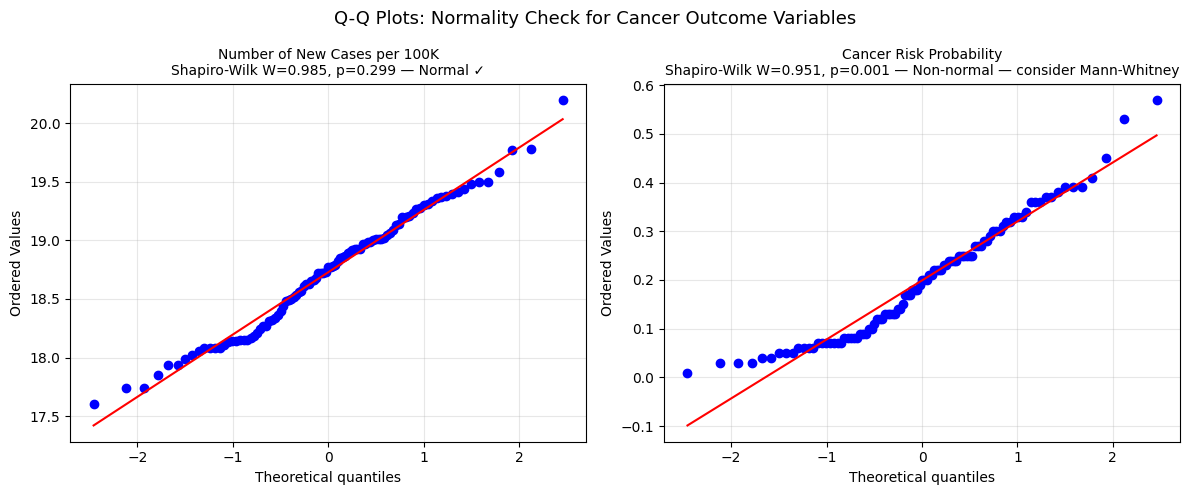

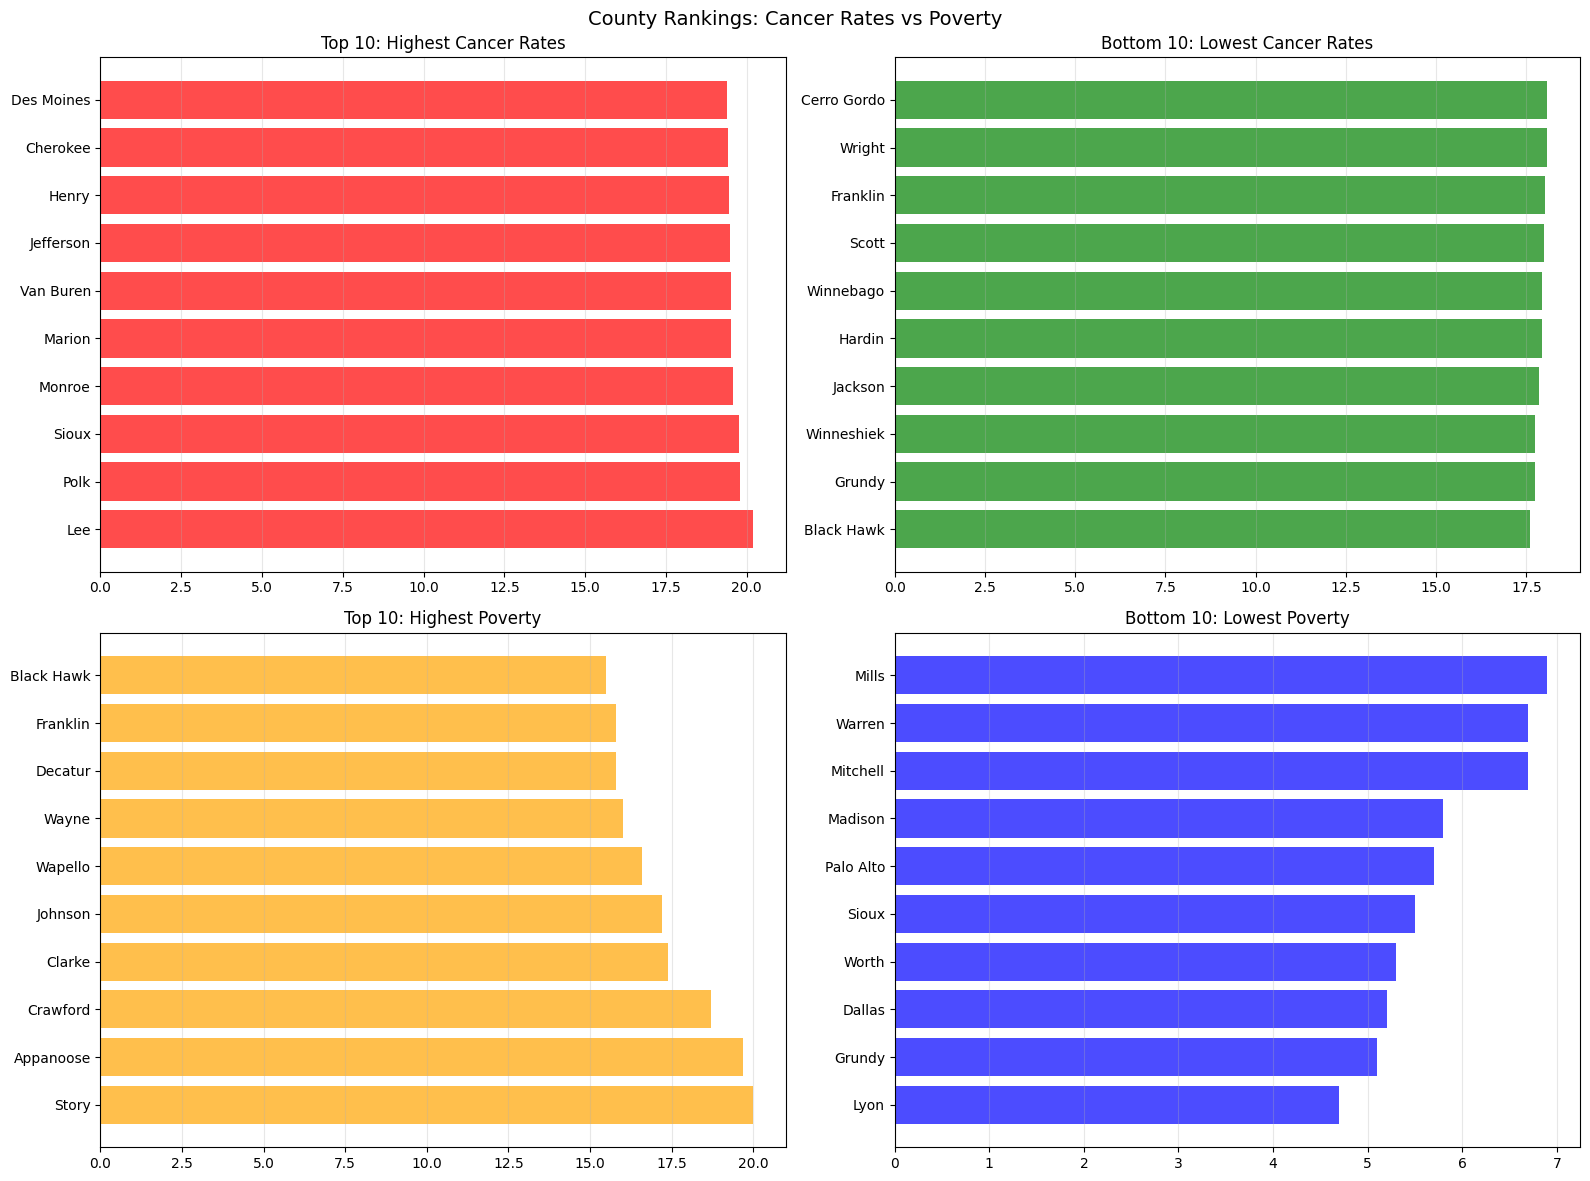

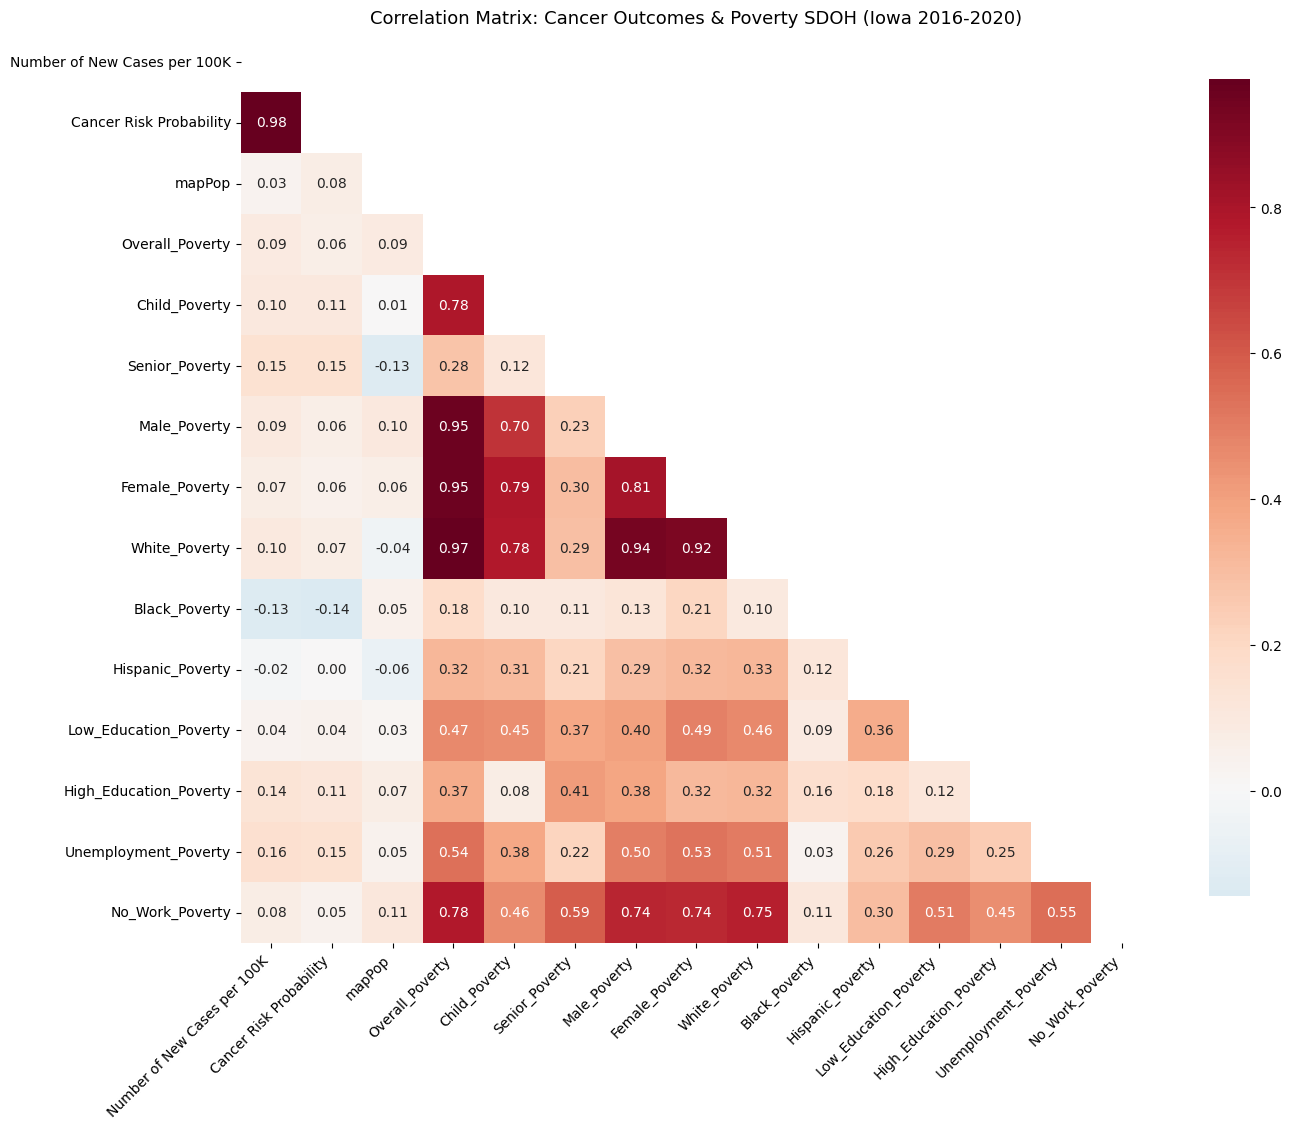

Split at median 10.9%: 51 low, 48 high poverty counties


/tmp/ipykernel_11252/3729077905.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([low[col].dropna(), high[col].dropna()],
/tmp/ipykernel_11252/3729077905.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([low[col].dropna(), high[col].dropna()],


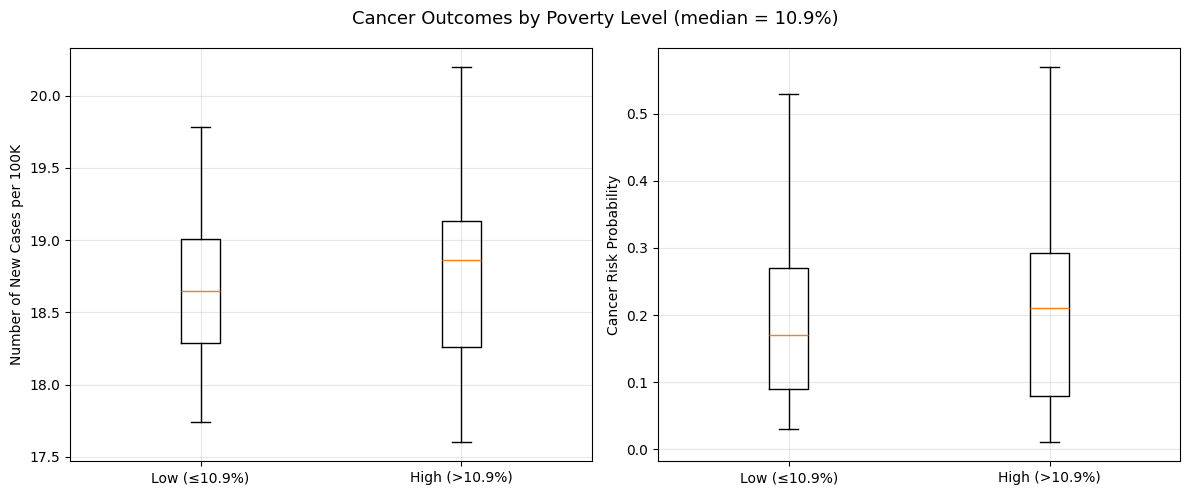

Number of New Cases per 100K: t=-0.704, p=0.483 — not significant
Cancer Risk Probability: t=-0.630, p=0.530 — not significant


In [6]:
# ── Q-Q plots: normality check (validates t-test assumption) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['Number of New Cases per 100K','Cancer Risk Probability']):
    vals = poverty_df[col].dropna()
    probplot(vals, dist='norm', plot=ax)
    stat, p = shapiro(vals)
    ax.set_title(f'{col}\nShapiro-Wilk W={stat:.3f}, p={p:.3f} — '
                 f'{"Normal ✓" if p>0.05 else "Non-normal — consider Mann-Whitney"}', fontsize=10)
    ax.grid(True, alpha=0.3)
plt.suptitle('Q-Q Plots: Normality Check for Cancer Outcome Variables', fontsize=13)
plt.tight_layout(); plt.show()

# ── Top / bottom county rankings ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax,(col,largest,color,title) in zip(axes.flat,[
    ('Number of New Cases per 100K',True, 'red',   'Top 10: Highest Cancer Rates'),
    ('Number of New Cases per 100K',False,'green', 'Bottom 10: Lowest Cancer Rates'),
    ('Overall_Poverty',             True, 'orange','Top 10: Highest Poverty'),
    ('Overall_Poverty',             False,'blue',  'Bottom 10: Lowest Poverty')]):
    grp = poverty_df.nlargest(10,col) if largest else poverty_df.nsmallest(10,col)
    ax.barh(range(len(grp)), grp[col], color=color, alpha=0.7)
    ax.set_yticks(range(len(grp))); ax.set_yticklabels(grp['County'])
    ax.set_title(title); ax.grid(axis='x', alpha=0.3)
plt.suptitle('County Rankings: Cancer Rates vs Poverty', fontsize=14)
plt.tight_layout(); plt.show()

# ── Correlation heatmap ───────────────────────────────────────────────────────
corr_vars = ['Number of New Cases per 100K','Cancer Risk Probability','mapPop'] + list(sdoh_categories)
corr_data = poverty_df[corr_vars].apply(pd.to_numeric, errors='coerce').corr()  # no fillna(0)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_data, mask=np.triu(np.ones_like(corr_data,dtype=bool)),
            annot=True, cmap='RdBu_r', center=0, square=True, fmt='.2f',
            cbar_kws={'shrink':.8}, ax=ax)
ax.set_title('Correlation Matrix: Cancer Outcomes & Poverty SDOH (Iowa 2016-2020)', fontsize=13)
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# ── Box plots + t-tests: high vs low poverty (median_pov from prep cell) ─────
high = poverty_df[poverty_df['Overall_Poverty'] >  median_pov]
low  = poverty_df[poverty_df['Overall_Poverty'] <= median_pov]
print(f"Split at median {median_pov:.1f}%: {len(low)} low, {len(high)} high poverty counties")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['Number of New Cases per 100K','Cancer Risk Probability']):
    ax.boxplot([low[col].dropna(), high[col].dropna()],
               labels=[f'Low (≤{median_pov:.1f}%)',f'High (>{median_pov:.1f}%)'])
    ax.set_ylabel(col); ax.grid(True, alpha=0.3)
plt.suptitle(f'Cancer Outcomes by Poverty Level (median = {median_pov:.1f}%)', fontsize=13)
plt.tight_layout(); plt.show()

for col in ['Number of New Cases per 100K','Cancer Risk Probability']:
    t, p = ttest_ind(low[col].dropna(), high[col].dropna())
    print(f"{col}: t={t:.3f}, p={p:.3f} — {'significant' if p<0.05 else 'not significant'}")


### **Poverty vs Cancer Univariate Analysis and Real-World Insights<br>**
No Meaningful Relationship. The univariate analysis reveals that poverty has essentially no relationship with cancer risk in Iowa counties:

**Actual Correlation Results:** <br>
Overall Poverty vs Number of New Cases per 100K: r = 0.090 (p = 0.376)
Overall Poverty vs Cancer Risk Probability: r = 0.065 (p = 0.525)
What This Means:

Both correlations are extremely weak (under 0.1) <br>
Both are statistically non-significant (p-values well above 0.05) <br>
The scatterplots show "random scatter patterns" with "no clear upward or downward trend" <br>
Cancer rates remain consistent "around 18-20 cases per 100K across all poverty levels" <br>

**The Real-World Implication:**
Contrary to common assumptions, poverty alone does not predict cancer risk in Iowa. Counties with 4% poverty rates have similar cancer outcomes to counties with 20% poverty rates. This suggests that other factors (not economic status itself) are driving cancer disparities.

**What This Doesn't Mean:**
This doesn't mean poverty has no health impacts - just that at the county level in Iowa, poverty rates don't correlate with colorectal cancer incidence. The relationship may exist at individual levels, in other states, or for other health conditions, but it's simply not present in this specific dataset.

The analysis definitively shows that poverty, by itself, is not a predictor of cancer risk in Iowa counties.